# US Treasury ETF Rotation — Strategy Notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import requests
import yaml
from pathlib import Path
from datetime import datetime, timedelta
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
CONFIG_PATH = Path('../data_preparation/data_apiKey/config.yaml')
with open(CONFIG_PATH) as f:
    config = yaml.safe_load(f)
API_KEY = config['keys']['fmp_api_key']

### 1. Data Acquisition

In [3]:
def fetch_treasury_rates(start, end, api_key):
    all_data = []
    cur = pd.Timestamp(start)
    end_dt = pd.Timestamp(end)
    while cur < end_dt:
        window_end = min(cur + timedelta(days=89), end_dt)
        url = (
            f'https://financialmodelingprep.com/stable/treasury-rates'
            f'?from={cur.strftime("%Y-%m-%d")}'
            f'&to={window_end.strftime("%Y-%m-%d")}'
            f'&apikey={api_key}'
        )
        try:
            resp = requests.get(url, timeout=15)
            data = resp.json()
            if isinstance(data, list):
                all_data.extend(data)
        except Exception as e:
            print(f'Error fetching {cur} - {window_end}: {e}')
        cur = window_end + timedelta(days=1)
    
    df = pd.DataFrame(all_data)
    if df.empty:
        return df
    df['date'] = pd.to_datetime(df['date'])
    df.set_index('date', inplace=True)
    df.sort_index(inplace=True)
    return df.apply(pd.to_numeric, errors='coerce')

rates = fetch_treasury_rates('2010-01-01', datetime.now().strftime('%Y-%m-%d'), API_KEY)
print(f'Treasury rates: {rates.shape[0]} rows, {rates.columns.tolist()}')
rates

Treasury rates: 4046 rows, ['month1', 'month2', 'month3', 'month6', 'year1', 'year2', 'year3', 'year5', 'year7', 'year10', 'year20', 'year30']


,month1,month2,month3,month6,year1,year2,year3,year5,year7,year10,year20,year30
date,,,,,,,,,,,,
2010-01-04,0.05,NaN,0.08,0.18,0.45,1.09,1.66,2.65,3.36,3.85,4.60,4.65
2010-01-05,0.03,NaN,0.07,0.17,0.41,1.01,1.57,2.56,3.28,3.77,4.54,4.59
2010-01-06,0.03,NaN,0.06,0.15,0.40,1.01,1.60,2.60,3.33,3.85,4.63,4.70
2010-01-07,0.02,NaN,0.05,0.16,0.40,1.03,1.62,2.62,3.33,3.85,4.62,4.69
2010-01-08,0.02,NaN,0.05,0.15,0.37,0.96,1.56,2.57,3.31,3.83,4.61,4.70
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-02,3.74,3.74,3.72,3.68,3.54,3.47,3.49,3.62,3.82,4.05,4.64,4.70
2026-03-03,3.75,3.74,3.71,3.68,3.55,3.51,3.50,3.63,3.83,4.06,4.65,4.70
2026-03-04,3.75,3.75,3.71,3.68,3.58,3.54,3.55,3.67,3.87,4.09,4.67,4.72


In [4]:
etf_map = {
    'BIL': '0-1Y',
    'SHY': '1-3Y',
    'IEI': '3-7Y',
    'IEF': '7-10Y',
    'TLH': '10-20Y',
    'TLT': '20+Y',
}

def fetch_etf_price(symbol, api_key, start_date='2010-01-01', end_date=datetime.now().strftime('%Y-%m-%d')):
    url = (
        f'https://financialmodelingprep.com/stable/historical-price-eod/full'
        f'?symbol={symbol}&from={start_date}&to={end_date}&apikey={api_key}'
    )
    for attempt in range(3):
        try:
            resp = requests.get(url, timeout=15)
            data = resp.json()
            if isinstance(data, list) and len(data) > 0:
                df = pd.DataFrame(data)
                df['date'] = pd.to_datetime(df['date'])
                price_col = 'adjClose' if 'adjClose' in df.columns else 'close'
                df = df[['date', price_col]].sort_values('date')
                df.set_index('date', inplace=True)
                return df[price_col].rename(symbol)
            else:
                if attempt == 2:
                    print(f' [resp type={type(data).__name__}, keys={list(data.keys()) if isinstance(data,dict) else "N/A"}]', end='')
        except Exception as e:
            if attempt == 2:
                print(f' [err: {e}]', end='')
    return pd.Series(dtype=float, name=symbol)

dfs = {}
for ticker in etf_map:
    print(f'  {ticker} ...', end='')
    s = fetch_etf_price(ticker, API_KEY, start_date='2010-01-01', end_date=datetime.now().strftime('%Y-%m-%d'))
    if not s.empty:
        dfs[ticker] = s
        print(f' {len(s)} pts')
    else:
        print(' FAILED')

prices = pd.DataFrame(dfs)
prices = prices.loc['2010':].ffill().dropna()
rets = prices.pct_change().dropna()
print(f'\nPrice matrix: {prices.shape}')
prices

  BIL ... 4068 pts
  SHY ... 4068 pts
  IEI ... 4068 pts
  IEF ... 4068 pts
  TLH ... 4068 pts
  TLT ... 4068 pts

Price matrix: (4068, 6)


,BIL,SHY,IEI,IEF,TLH,TLT
date,,,,,,
2010-01-04,91.70,83.07,110.24,88.82,106.58,89.81
2010-01-05,91.68,83.17,110.59,89.21,107.16,90.39
2010-01-06,91.68,83.18,110.44,88.85,106.48,89.18
2010-01-07,91.68,83.16,110.40,88.85,106.58,89.33
2010-01-08,91.68,83.24,110.56,88.96,106.78,89.29
...,...,...,...,...,...,...
2026-03-02,91.39,82.81,119.88,97.12,103.78,89.61
2026-03-03,91.40,82.80,119.82,97.01,103.59,89.43
2026-03-04,91.41,82.75,119.60,96.81,103.33,89.15


### 2. Yield Curve Visualization

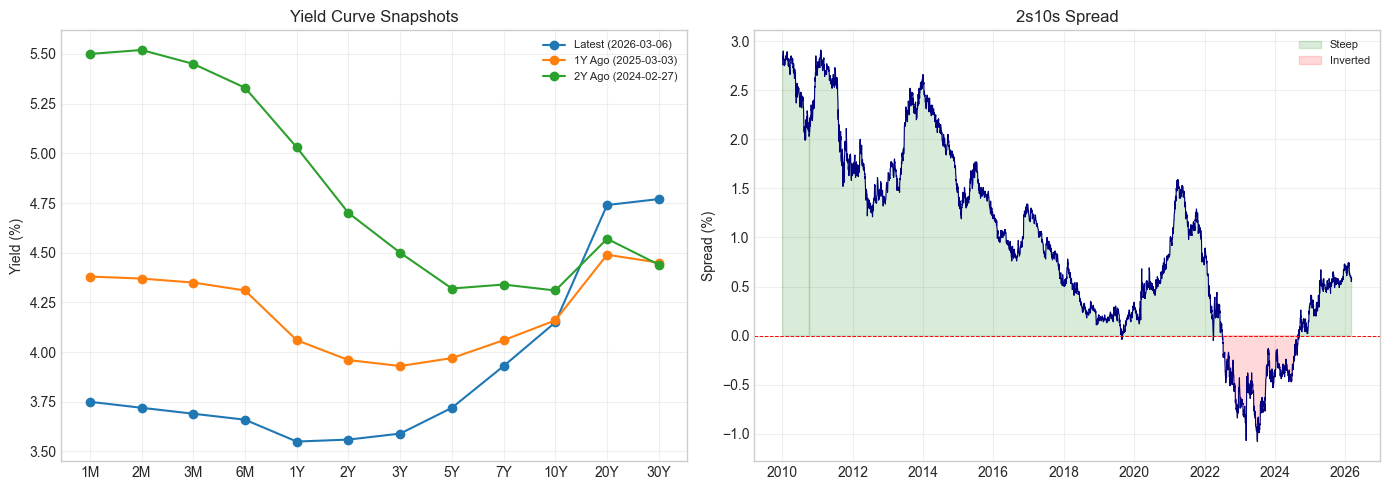

In [5]:
tenor_months = [1, 2, 3, 6, 12, 24, 36, 60, 84, 120, 240, 360]
tenor_labels = ['1M','2M','3M','6M','1Y','2Y','3Y','5Y','7Y','10Y','20Y','30Y']
rate_cols = ['month1','month2','month3','month6','year1','year2','year3','year5','year7','year10','year20','year30']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for offset, color, label in [(0,'#1f77b4','Latest'), (252,'#ff7f0e','1Y Ago'), (504,'#2ca02c','2Y Ago')]:
    idx = min(offset, len(rates)-1)
    row = rates[rate_cols].iloc[-(idx+1)]
    axes[0].plot(tenor_labels, row.values, 'o-', color=color, label=f'{label} ({rates.index[-(idx+1)].date()})')
axes[0].set_title('Yield Curve Snapshots')
axes[0].set_ylabel('Yield (%)')
axes[0].legend(fontsize=8)

spread_2s10s = rates['year10'] - rates['year2']
axes[1].plot(spread_2s10s.index, spread_2s10s, color='navy', lw=0.8)
axes[1].axhline(0, color='red', ls='--', lw=0.7)
axes[1].fill_between(spread_2s10s.index, spread_2s10s, 0, 
                     where=spread_2s10s>0, alpha=0.15, color='green', label='Steep')
axes[1].fill_between(spread_2s10s.index, spread_2s10s, 0,
                     where=spread_2s10s<0, alpha=0.15, color='red', label='Inverted')
axes[1].set_title('2s10s Spread')
axes[1].set_ylabel('Spread (%)')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

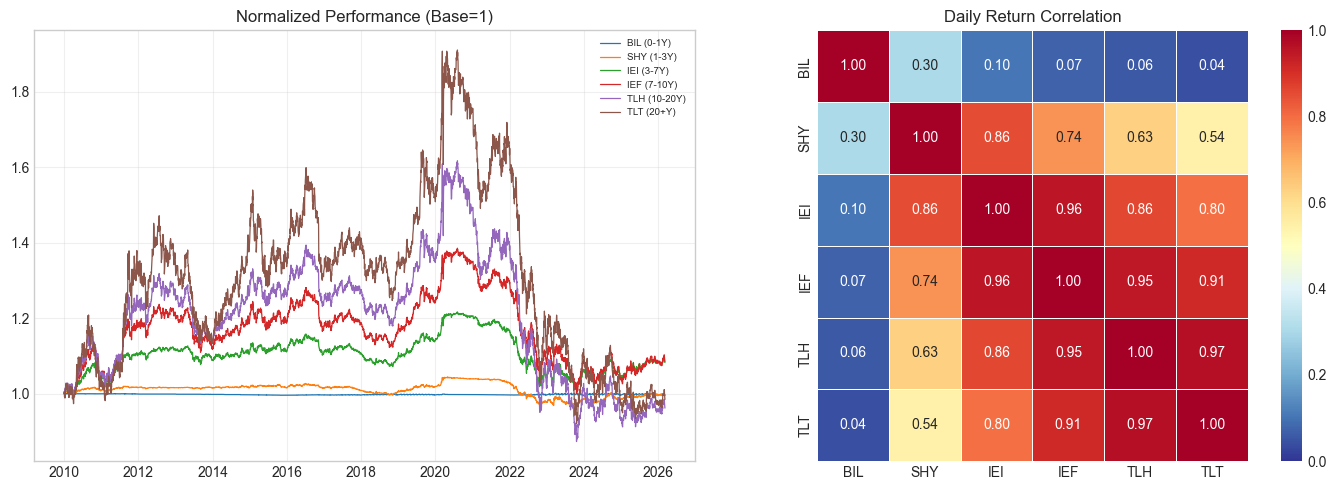

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

norm = prices / prices.iloc[0]
for col in prices.columns:
    axes[0].plot(norm.index, norm[col], label=f'{col} ({etf_map.get(col,"")})', lw=0.9)
axes[0].set_title('Normalized Performance (Base=1)')
axes[0].legend(fontsize=7)

corr = rets.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlBu_r', vmin=0, vmax=1,
            square=True, ax=axes[1], linewidths=0.5)
axes[1].set_title('Daily Return Correlation')
plt.tight_layout()
plt.show()

### 3. Backtest Utilities

In [7]:
def backtest_weights(weights_df, returns_df, tc_bps=3):
    common = weights_df.index.intersection(returns_df.index)
    w = weights_df.loc[common]
    r = returns_df.loc[common]
    port_ret = (w.shift(1) * r).sum(axis=1).dropna()
    turnover = w.diff().abs().sum(axis=1) / 2
    tc = turnover * tc_bps / 10000
    port_ret_net = port_ret - tc
    return port_ret_net

def perf_stats(ret_series, name='Strategy', rf=0.0, bm_series=None):
    ann_ret = ret_series.mean() * 252
    ann_vol = ret_series.std() * np.sqrt(252)
    sharpe = (ann_ret - rf) / ann_vol if ann_vol > 0 else 0
    cum = (1 + ret_series).cumprod()
    dd = cum / cum.cummax() - 1
    max_dd = dd.min()
    calmar = ann_ret / abs(max_dd) if max_dd != 0 else 0

    result = {
        'Ann Return': f'{ann_ret:.2%}',
        'Ann Vol': f'{ann_vol:.2%}',
        'Sharpe': f'{sharpe:.3f}',
        'Max DD': f'{max_dd:.2%}',
        'Calmar': f'{calmar:.3f}',
    }

    if bm_series is not None:
        common_idx = ret_series.index.intersection(bm_series.index)
        excess = ret_series.loc[common_idx] - bm_series.loc[common_idx]
        excess = excess.dropna()
        if len(excess) > 1 and excess.std() > 0:
            rel_sharpe = (excess.mean() * 252) / (excess.std() * np.sqrt(252))
            result['Rel Sharpe'] = f'{rel_sharpe:.3f}'
        else:
            result['Rel Sharpe'] = 'N/A'
    return pd.Series(result, name=name)

def plot_equity(ret_dict, title='Strategy Comparison', benchmark_key=None):
    all_idx = None
    for name, ret in ret_dict.items():
        if all_idx is None:
            all_idx = ret.dropna().index
        else:
            start = max(all_idx[0], ret.dropna().index[0])
            end   = min(all_idx[-1], ret.dropna().index[-1])
            all_idx = all_idx[(all_idx >= start) & (all_idx <= end)]
    aligned = {name: ret.reindex(all_idx).fillna(0) for name, ret in ret_dict.items()}

    has_bm = benchmark_key is not None and benchmark_key in aligned

    fig, axes = plt.subplots(2, 1, figsize=(13, 7), height_ratios=[3, 1], sharex=True)

    for name, ret in aligned.items():
        cum = (1 + ret).cumprod()
        lw = 1.5 if name == benchmark_key else 0.9
        ls = '--' if name == benchmark_key else '-'
        axes[0].plot(cum.index, cum, label=name, lw=lw, ls=ls)
        dd = cum / cum.cummax() - 1
        axes[1].fill_between(dd.index, dd, 0, alpha=0.3, label=name)

    if has_bm:
        strat_key = [k for k in aligned if k != benchmark_key][0]
        excess_ret = aligned[strat_key] - aligned[benchmark_key]
        excess_cum = (1 + excess_ret).cumprod()
        ax2 = axes[0].twinx()
        ax2.plot(excess_cum.index, excess_cum, color='red', lw=0.7, alpha=0.6, label='Excess (right)')
        ax2.set_ylabel('Excess Cumulative', color='red', fontsize=9)
        ax2.tick_params(axis='y', labelcolor='red')
        if excess_ret.std() > 0:
            rel_sh = (excess_ret.mean() * 252) / (excess_ret.std() * np.sqrt(252))
            ax2.annotate(f'Rel Sharpe={rel_sh:.3f}', xy=(0.98, 0.02),
                         xycoords='axes fraction', ha='right', va='bottom',
                         fontsize=9, color='red',
                         bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))

    axes[0].set_title(title)
    axes[0].set_ylabel('Cumulative Return')
    axes[0].legend(fontsize=8, loc='upper left')
    axes[1].set_ylabel('Drawdown')
    axes[1].legend(fontsize=7)
    plt.tight_layout()
    plt.show()

### 4. Strategy 1 — Slope Z-Score Rotation

2s10s spread的z-score直接映射到duration倾斜:
- z > 0 (曲线陡峭) → 偏向短久期
- z < 0 (曲线平坦/倒挂) → 偏向长久期
- 用幂函数做连续权重分配

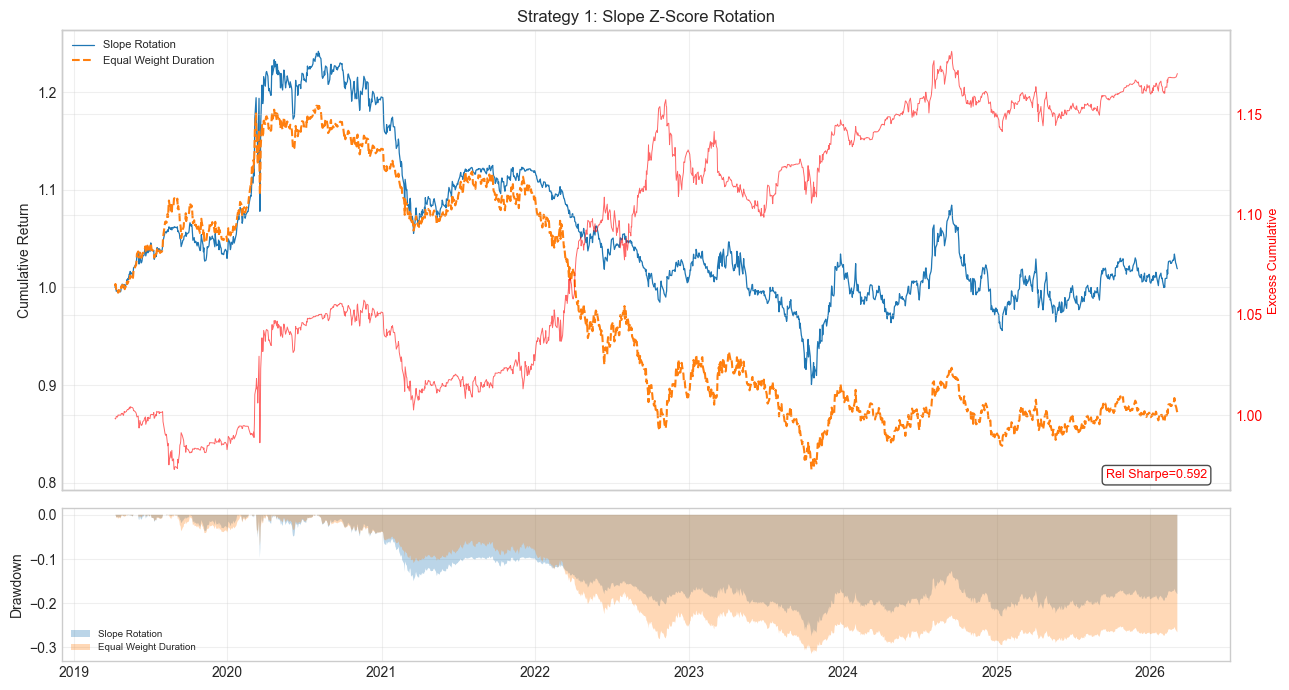

,Ann Return,Ann Vol,Sharpe,Max DD,Calmar,Rel Sharpe
Slope Rotation,0.72%,9.44%,0.076,-27.47%,0.026,0.592
Equal Weight,0.50%,7.16%,0.070,-31.51%,0.016,N/A


In [8]:
rates_aligned = rates.reindex(prices.index).ffill().dropna()
spread = rates_aligned['year10'] - rates_aligned['year2']
all_etfs = list(etf_map.keys())
dur_etfs = ['SHY', 'IEI', 'IEF', 'TLH', 'TLT']

key_rates = rates_aligned[['year2', 'year5', 'year10']].dropna()
level = key_rates.mean(axis=1)
slope = key_rates['year10'] - key_rates['year2']
curvature = 2 * key_rates['year5'] - key_rates['year2'] - key_rates['year10']

w_eq = pd.DataFrame(1/len(dur_etfs), index=rets[dur_etfs].dropna().index, columns=dur_etfs)
ret_eq = backtest_weights(w_eq, rets[dur_etfs])
ret_eq.name = 'Equal Weight'
bm = ret_eq.copy()

window = 120
spread_z = (spread - spread.rolling(window).mean()) / spread.rolling(window).std().clip(lower=0.001)
spread_z = spread_z.clip(-3, 3).dropna()

dur_scores = np.array([1, 2, 3, 4, 5], dtype=float)

w_slope = pd.DataFrame(index=spread_z.index, columns=dur_etfs, dtype=float)
for dt in w_slope.index:
    z = spread_z.loc[dt]
    tilt = z
    raw_w = dur_scores ** tilt
    w_slope.loc[dt] = raw_w / raw_w.sum()

ret_slope = backtest_weights(w_slope, rets[dur_etfs])
ret_slope.name = 'Slope Rotation'

plot_equity({'Slope Rotation': ret_slope, 'Equal Weight Duration': ret_eq},
            'Strategy 1: Slope Z-Score Rotation', benchmark_key='Equal Weight Duration')
pd.DataFrame([perf_stats(ret_slope, 'Slope Rotation', bm_series=bm),
              perf_stats(ret_eq, 'Equal Weight', bm_series=bm)])

### 5. Strategy 2 — Risk Parity + Momentum Overlay

逆波动率权重(30d) + 60日动量叠加，50/50混合，月度再平衡。

| Component | Method |
|-----------|--------|
| Risk Parity | `w ∝ 1 / σ_30d` |
| Momentum | Centered 60-day return → softmax |
| Blend | 50/50 |
| Rebalance | Monthly |

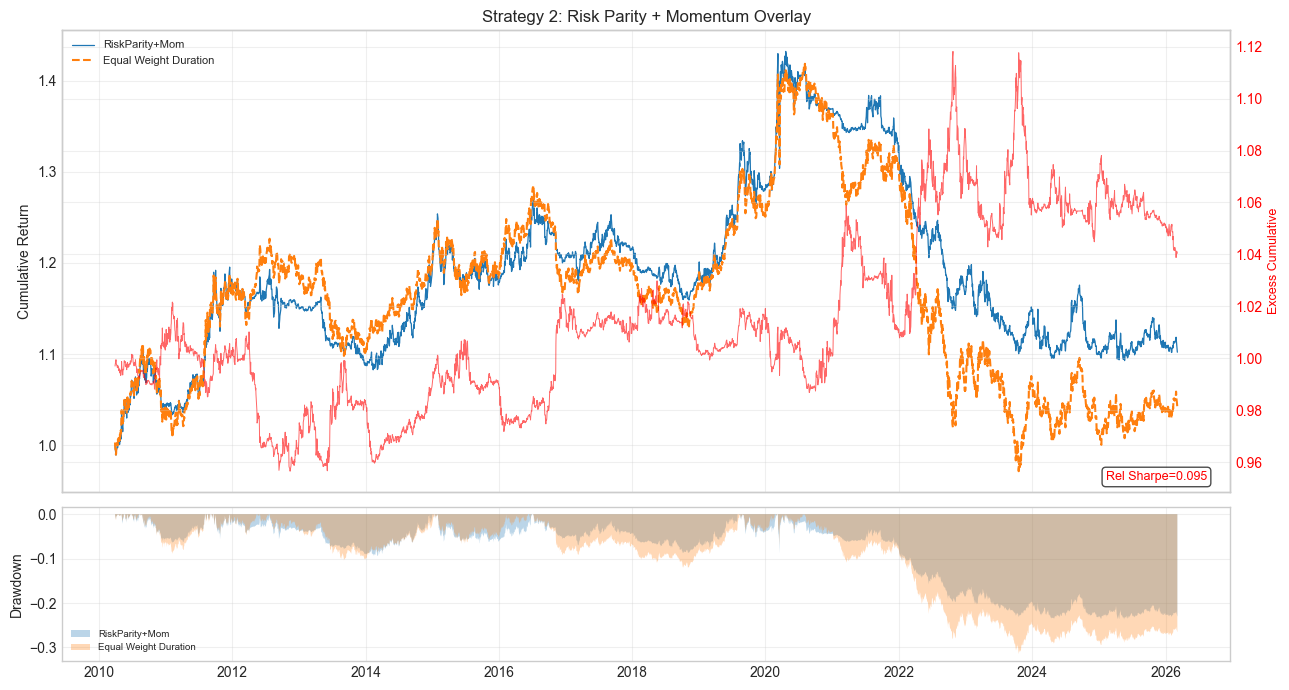

,Ann Return,Ann Vol,Sharpe,Max DD,Calmar,Rel Sharpe
RiskParity+Mom,0.81%,6.35%,0.128,-23.68%,0.034,0.095
Equal Weight,0.50%,7.16%,0.070,-31.51%,0.016,N/A


In [9]:
roll_vol = rets[dur_etfs].rolling(30).std() * np.sqrt(252)
roll_vol = roll_vol.dropna()

inv_vol = 1.0 / roll_vol.clip(lower=0.001)
w_rp = inv_vol.div(inv_vol.sum(axis=1), axis=0)

mom60 = prices[dur_etfs].pct_change(60)
mom_centered = mom60.sub(mom60.mean(axis=1), axis=0)
mom_scale = mom_centered.abs().mean(axis=1).clip(lower=0.001)
mom_exp = np.exp(1.5 * mom_centered.div(mom_scale, axis=0))
w_mom_overlay = mom_exp.div(mom_exp.sum(axis=1), axis=0)

common = w_rp.index.intersection(w_mom_overlay.dropna().index)
w_rp_mom = 0.5 * w_rp.loc[common] + 0.5 * w_mom_overlay.loc[common]
w_rp_mom = w_rp_mom.dropna()

w_rp_mom_monthly = w_rp_mom.resample('ME').last().reindex(w_rp_mom.index, method='ffill')

ret_rp = backtest_weights(w_rp_mom_monthly, rets[dur_etfs])
ret_rp.name = 'RiskParity+Mom'

plot_equity({'RiskParity+Mom': ret_rp, 'Equal Weight Duration': ret_eq},
            'Strategy 2: Risk Parity + Momentum Overlay', benchmark_key='Equal Weight Duration')
pd.DataFrame([perf_stats(ret_rp, 'RiskParity+Mom', bm_series=bm),
              perf_stats(ret_eq, 'Equal Weight', bm_series=bm)])

### 6. Strategy 3 — Cross-Sectional Momentum

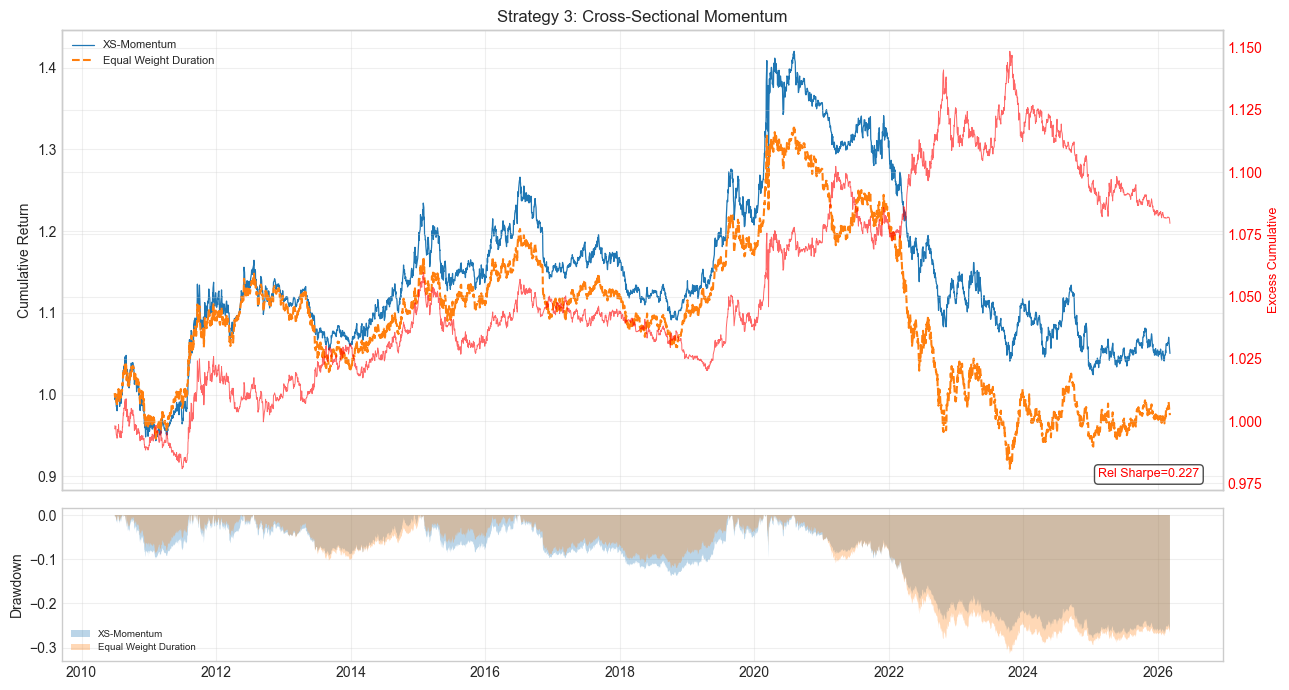

,Ann Return,Ann Vol,Sharpe,Max DD,Calmar,Rel Sharpe
XS-Momentum,0.61%,7.68%,0.079,-27.85%,0.022,0.227
Equal Weight,0.50%,7.16%,0.070,-31.51%,0.016,N/A


In [10]:
mom120 = prices[dur_etfs].pct_change(120).dropna()
mom_rank = mom120.rank(axis=1, ascending=True)
w_xsmom = mom_rank.div(mom_rank.sum(axis=1), axis=0)
w_xsmom = w_xsmom.resample('ME').last().reindex(w_xsmom.index, method='ffill').dropna()

ret_xsmom = backtest_weights(w_xsmom, rets[dur_etfs])
ret_xsmom.name = 'XS-Momentum'

plot_equity({'XS-Momentum': ret_xsmom, 'Equal Weight Duration': ret_eq}, 'Strategy 3: Cross-Sectional Momentum', benchmark_key='Equal Weight Duration')
pd.DataFrame([perf_stats(ret_xsmom, 'XS-Momentum', bm_series=bm), perf_stats(ret_eq, 'Equal Weight', bm_series=bm)])

### Position Export

In [ ]:
import os, requests as _req
from datetime import datetime as _dt

def _fmp_ids(tickers, api_key):
    out = {}
    for t in tickers:
        try:
            r = _req.get(f"https://financialmodelingprep.com/stable/profile?symbol={t}&apikey={api_key}", timeout=10)
            d = r.json()
            out[t] = (d[0].get("cusip","") if d else "", d[0].get("isin","") if d else "")
        except Exception:
            out[t] = ("", "")
    return out

day = _dt.now().strftime("%Y%m%d")
latest_w = w_xsmom.iloc[-1]
tks = latest_w.index.tolist()
wts = latest_w.values / latest_w.values.sum()
ids = _fmp_ids(tks, API_KEY)

df_pos = pd.DataFrame({
    "ticker": tks,
    "cusip": [ids[t][0] for t in tks],
    "isin": [ids[t][1] for t in tks],
    "weight": wts,
    "order_time": "MOC",
    "order_type": "default"
})

out_dir = f"../execution_main/trading_log/{day}"
os.makedirs(out_dir, exist_ok=True)
df_pos.to_csv(f"{out_dir}/strategy_usTreasury_weight.csv", index=False)
print(f"→ {out_dir}/strategy_usTreasury_weight.csv  ({len(df_pos)} rows)")
df_pos